# Baseline CNN Training

This notebook trains a baseline convolutional neural network on CIFAR-10 using normalized training data. The model is evaluated on a validation set during training, and the checkpoint with the lowest validation loss is selected for final evaluation on the clean test set.

The resulting clean test performance will serve as the reference point for subsequent image corruption and robustness experiments.

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

# CIFAR-10 normalization statistics calculated from the training set
mean = [0.4914, 0.4822, 0.4465]
std = [0.2470, 0.2435, 0.2616]

normalized_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Load CIFAR-10 datasets
train_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=False,
    transform=normalized_transform
)

val_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=False,
    transform=normalized_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=False,
    download=False,
    transform=normalized_transform
)

# Create stratified train/validation indices
all_indices = np.arange(len(train_dataset))

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.1,
    random_state=42,
    stratify=train_dataset.targets
)

# Create train and validation subsets
train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

print("Training samples:", len(train_subset))
print("Validation samples:", len(val_subset))
print("Test samples:", len(test_dataset))

Training samples: 45000
Validation samples: 5000
Test samples: 10000


In [2]:
# Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

# Inspect one training batch
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([128, 3, 32, 32])
Batch label shape: torch.Size([128])


In [3]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BaselineCNN()

print(model)

images, label = next(iter(train_loader))
outputs = model(images)

print("\nInput shape:", images.shape)
print("Output shape:", outputs.shape)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Input shape: torch.Size([128, 3, 32, 32])
Output shape: torch.Size([128, 10])


In [4]:
# Set random seed for reproducibility
torch.manual_seed(42)

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Initialize model
model = BaselineCNN().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# Check loss on one batch
images, labels = next(iter(val_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)
loss = criterion(outputs, labels)

print("\nOutput shape:", outputs.shape)
print("Labels shape:", labels.shape)
print("Initial loss:", loss.item())

Device: cuda

Output shape: torch.Size([128, 10])
Labels shape: torch.Size([128])
Initial loss: 2.3097383975982666


In [5]:
# Create directory for model checkpoints
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

checkpoint_path = models_dir / "baseline_cnn_best.pth"

# Training settings
num_epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
best_epoch = 0

for epoch in range(num_epochs):
    # Training
    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_train_loss / train_total
    train_accuracy = train_correct / train_total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Validation
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = running_val_loss / val_total
    val_accuracy = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Save the model with the lowest validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            checkpoint_path
        )

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

print(
    f"\nBest model: Epoch {best_epoch} "
    f"with validation loss {best_val_loss:.4f}"
)

Epoch 01/10 | Train Loss: 1.4745 | Train Acc: 0.4706 | Val Loss: 1.1290 | Val Acc: 0.5998
Epoch 02/10 | Train Loss: 1.1077 | Train Acc: 0.6059 | Val Loss: 0.9791 | Val Acc: 0.6638
Epoch 03/10 | Train Loss: 0.9466 | Train Acc: 0.6659 | Val Loss: 0.8852 | Val Acc: 0.6890
Epoch 04/10 | Train Loss: 0.8531 | Train Acc: 0.6984 | Val Loss: 0.8515 | Val Acc: 0.6990
Epoch 05/10 | Train Loss: 0.7638 | Train Acc: 0.7324 | Val Loss: 0.8030 | Val Acc: 0.7158
Epoch 06/10 | Train Loss: 0.6925 | Train Acc: 0.7544 | Val Loss: 0.7962 | Val Acc: 0.7202
Epoch 07/10 | Train Loss: 0.6284 | Train Acc: 0.7763 | Val Loss: 0.8155 | Val Acc: 0.7194
Epoch 08/10 | Train Loss: 0.5657 | Train Acc: 0.8012 | Val Loss: 0.8239 | Val Acc: 0.7172
Epoch 09/10 | Train Loss: 0.5189 | Train Acc: 0.8157 | Val Loss: 0.8073 | Val Acc: 0.7274
Epoch 10/10 | Train Loss: 0.4732 | Train Acc: 0.8311 | Val Loss: 0.8385 | Val Acc: 0.7308

Best model: Epoch 6 with validation loss 0.7962


### Baseline Training Observations

The baseline CNN learned steadily over 10 epochs, with training accuracy increasing from 47.06% to 83.11% and validation accuracy improving from 59.98% to 73.08%.

Validation loss reached its minimum of 0.7962 at epoch 6, after which it began to fluctuate while training loss continued to decrease. This suggests early signs of overfitting as the model continued to improve on the training data without corresponding improvements in validation loss.

The model checkpoint from epoch 6 was therefore selected based on the lowest validation loss for subsequent clean test evaluation.

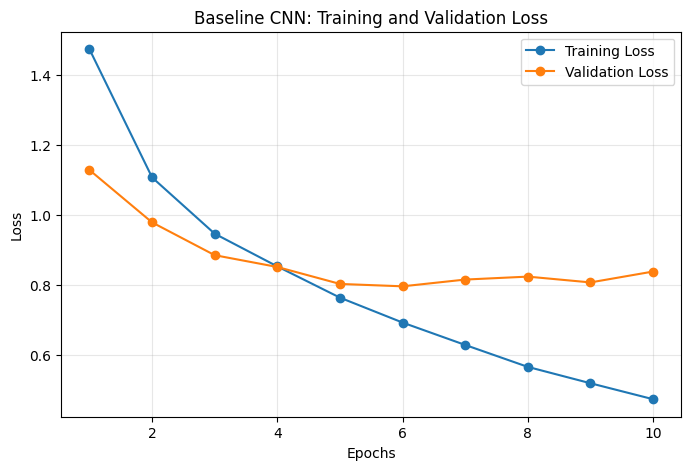

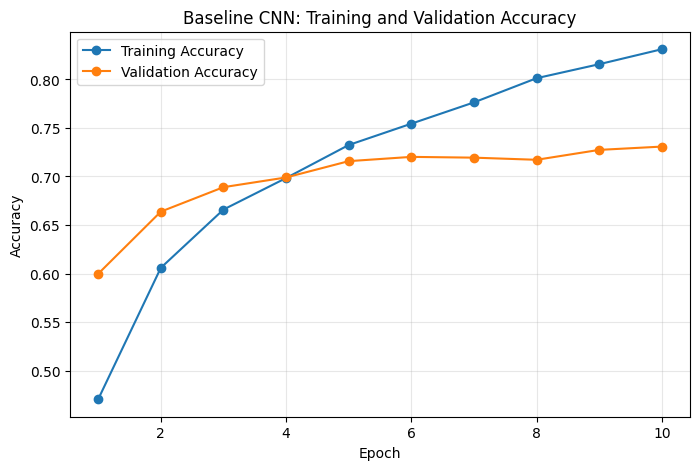

In [6]:
epochs = range(1, num_epochs + 1)

# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, marker="o", label="Training Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Baseline CNN: Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_accuracies, marker="o", label="Training Accuracy")
plt.plot(epochs, val_accuracies, marker="o", label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN: Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [7]:
# Load the best validation model
best_model = BaselineCNN().to(device)

best_model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=True
    )
)

best_model.eval()

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [8]:
# Evaluate on the clean test set
running_test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        loss = criterion(outputs, labels)

        running_test_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        test_correct += (predictions == labels).sum().item()
        test_total += labels.size(0)

test_loss = running_test_loss / test_total
test_accuracy = test_correct / test_total

print(f"Clean Test Loss: {test_loss:.4f}")
print(f"Clean Test Accuracy: {test_accuracy:.4f}")

Clean Test Loss: 0.8143
Clean Test Accuracy: 0.7152


### Clean Test Performance

The checkpoint with the lowest validation loss was selected for final evaluation on the untouched CIFAR-10 test set. The selected model, from epoch 6, achieved a clean test loss of 0.8143 and a test accuracy of 71.52%.

The test performance was close to the corresponding validation performance, where the model achieved a validation loss of 0.7962 and an accuracy of 72.02%. This suggests that the selected baseline generalizes similarly to unseen validation and test data.

The clean test accuracy of 71.52% will serve as the reference point for subsequent image corruption experiments, where robustness will be evaluated based on performance degradation relative to this baseline.